In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
from mplsoccer import Pitch
from statsbombpy import sb

# Silencia os avisos de falta de credenciais da API pública do StatsBomb
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*credentials were not supplied*")

In [2]:
competitions = sb.competitions()

competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [3]:
matches = sb.matches(
    competition_id=9,
    season_id=281
)

matches.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3895292,2024-04-06,15:30:00.000,0,1,available,available,2024-07-31T11:03:01.588127,2025-07-06T04:26:07.636270,28,...,Croatia,1000310,Xabier Alonso Olano,Xabi Alonso,1981-11-25,214,Spain,1.1.0,2,2
1,3895320,2024-04-27,19:30:00.000,2,2,available,available,2024-08-06T15:42:54.389576,2025-01-02T11:05:23.462823,31,...,Spain,5213,Sebastian Hoeneß,NaN,1982-05-12,85,Germany,1.1.0,2,2
2,3895158,2023-12-03,18:30:00.000,1,1,available,available,2024-07-29T12:45:28.152104,2025-09-07T09:35:11.061799,13,...,Spain,5531,Edin Terzić,NaN,1982-10-30,85,Germany,1.1.0,2,2
3,3895107,2023-10-08,16:30:00.000,3,0,available,available,2024-07-29T12:43:40.606973,2024-10-14T10:35:11.461679,7,...,Spain,104,Steffen Baumgart,NaN,1972-01-05,85,Germany,1.1.0,2,2
4,3895340,2024-05-12,20:30:00.000,0,5,available,available,2024-07-29T12:16:45.557236,2025-01-01T12:14:22.212709,33,...,Germany,1000310,Xabier Alonso Olano,Xabi Alonso,1981-11-25,214,Spain,1.1.0,2,2


In [4]:
matches[['home_team', 'away_team', 'match_id']]

,home_team,away_team,match_id
0,Union Berlin,Bayer Leverkusen,3895292
1,Bayer Leverkusen,VfB Stuttgart,3895320
2,Bayer Leverkusen,Borussia Dortmund,3895158
3,Bayer Leverkusen,FC Köln,3895107
4,Bochum,Bayer Leverkusen,3895340
5,Bayer Leverkusen,Hoffenheim,3895286
6,Bayer Leverkusen,Werder Bremen,3895302
7,Eintracht Frankfurt,Bayer Leverkusen,3895333
8,Bayer Leverkusen,Augsburg,3895348
9,Darmstadt 98,Bayer Leverkusen,3895220


In [5]:
home_team = matches.iloc[19]['home_team']
away_team = matches.iloc[19]['away_team']

print(home_team, "vs", away_team)

Borussia Dortmund vs Bayer Leverkusen


In [6]:
match_id = matches.iloc[19]['match_id']

In [7]:
events = sb.events(match_id=match_id)

In [8]:
events['type'].unique()

<ArrowStringArray>
[      'Starting XI',        'Half Start',              'Pass',
     'Ball Receipt*',             'Carry',          'Pressure',
              'Shot',       'Goal Keeper',      'Dispossessed',
              'Duel',     'Ball Recovery',     'Dribbled Past',
           'Dribble',    'Foul Committed',          'Foul Won',
      'Interception',             'Block',         'Clearance',
        'Miscontrol',    'Tactical Shift',             '50/50',
           'Offside',          'Half End',      'Substitution',
   'Injury Stoppage',        'Player Off', 'Referee Ball-Drop',
         'Player On',            'Shield',     'Bad Behaviour']
Length: 30, dtype: str

In [9]:
shots = events[events['type'] == 'Shot'].copy()

shots = shots.dropna(subset=['location'])

In [10]:
shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])

In [11]:
shots_home = shots[shots['team'] == home_team]
shots_away = shots[shots['team'] == away_team]

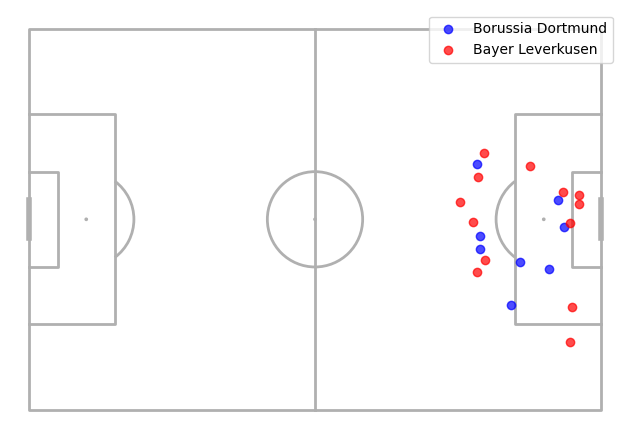

In [12]:
pitch = Pitch()
fig, ax = pitch.draw()

# HOME TEAM
ax.scatter(
    shots_home['x'],
    shots_home['y'],
    color='blue',
    label=home_team,
    alpha=0.7
)

# AWAY TEAM
ax.scatter(
    shots_away['x'],
    shots_away['y'],
    color='red',
    label=away_team,
    alpha=0.7
)

# =========================
# 10. LEGEND + SHOW
# =========================
ax.legend()
plt.show()